# 한국어, 중국어, 영어 예제

실제 문장에서 개체명 인식(NER), 관계 추출(Relation Extraction) 을 수행하고 시각화를 통해 정보추출의 전체 과정을 이해한다.

In [6]:
# 설치 (Colab / Jupyter Notebook)
!pip install spacy transformers torch networkx matplotlib
!python -m spacy download en_core_web_sm
!python -m spacy download zh_core_web_sm
!pip install spacy spacy-stanza kss transformers torch networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 36.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.0/163.0 kB 5.8 MB/s eta 0:00:00
     ━━━

In [9]:
import kss, spacy_stanza
from spacy import displacy

# 1) 한국어 파이프라인 로드 (Stanza를 spaCy 인터페이스로)
nlp_ko = spacy_stanza.load_pipeline("ko")  # 처음 실행 시 모델 다운로드가 자동 진행됨

# 2) 문장 분할(KSS)
text_ko = "이재용은 2025년에 서울에서 삼성전자 신제품을 발표했다. 이어서 글로벌 전략을 발표할 예정이다."
sents = list(kss.split_sentences(text_ko))
print("문장 분할:", sents)

# 3) 품사/의존 분석 + 시각화
doc_ko = nlp_ko(sents[0])
for token in doc_ko:
    print(f"{token.text:>8}  {token.pos_:<8}  head={token.head.text:<8}  dep={token.dep_}")

# 주피터/코랩에서 의존 시각화
displacy.render(doc_ko, style="dep", jupyter=True, options={"compact": True, "distance": 110})

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Loading these models for language: ko (Korean):
| Processor | Package        |
------------------------------
| tokenize  | kaist          |
| pos       | kaist_nocharlm |
| lemma     | kaist_nocharlm |
| depparse  | kaist_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: pos
/usr/local/lib/python3.12/dist-packages/torch/_weights_only_unpickler.py:549: UserWarning: Detected pickle protocol 3 in the checkpoint, which was not the default pickle protocol used by `torch.load` (2). The weights_only Unpickler might not support all instructions implemented by this protocol, please file an issue for adding support if you encounter this.
  warnings.warn(


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy.core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch

# ① 개체명 인식 (Named Entity Recognition, NER)

In [7]:
import spacy
from spacy import displacy

# 1) 영어 NER 모델 로드
nlp = spacy.load("en_core_web_sm")

# 2) 예문 입력
text = "Steve Jobs founded Apple in 1976 in California."
doc = nlp(text)

# 3) 개체명 인식 결과 출력
for ent in doc.ents:
    print(f"{ent.text:<15} | {ent.label_}")

# 4) 시각화
displacy.render(doc, style="ent", jupyter=True)

Steve Jobs      | PERSON
Apple           | ORG
1976            | DATE
California      | GPE


In [8]:
nlp_zh = spacy.load("zh_core_web_sm")

text_zh = "马云于1999年在杭州创立了阿里巴巴集团。"
doc_zh = nlp_zh(text_zh)

for ent in doc_zh.ents:
    print(f"{ent.text:<15} | {ent.label_}")

displacy.render(doc_zh, style="ent", jupyter=True)

马云于             | GPE
1999年           | DATE
杭州              | GPE
阿里巴巴集团          | ORG


# ② 관계 추출 Demo (Relation Extraction)

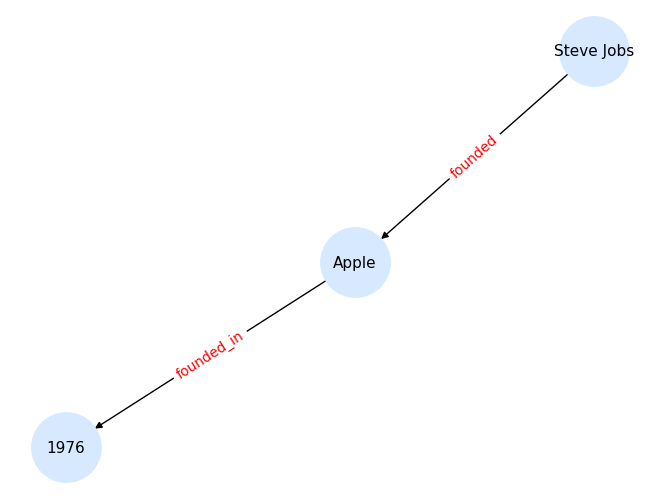

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 간단한 관계 트리플 정의
triples = [
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976")
]

# 그래프 생성
G = nx.DiGraph()
for h, r, t in triples:
    G.add_edge(h, t, label=r)

# 시각화
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, node_color="#D7E9FF", font_size=11)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.show()

# ③ Transformers 기반 NER (Hugging Face)

In [4]:
from transformers import pipeline

# 사전학습된 NER 모델 로드
ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

# 문장 입력
# 다른 문장: “Elon Musk acquired Twitter in 2022 for 44 billion dollars.”
result = ner("Steve Jobs founded Apple in 1976 in California.")

# 결과 출력
for r in result:
    print(f"{r['word']:<15} | {r['entity_group']:<10} | {r['score']:.3f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Steve Jobs      | PER        | 0.999
Apple           | ORG        | 0.999
California      | LOC        | 1.000


# 다국어 NER 실습

In [5]:
from transformers import pipeline
ner_ko = pipeline("ner", model="nlpaueb/bert-base-multilingual-cased-ner")
ner_ko("이재용은 2025년에 삼성전자를 이끌고 있다.")

OSError: nlpaueb/bert-base-multilingual-cased-ner is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`